# Lab 4 and 5

### **1. Objective**
- Implement a **Feed Forward Neural Network** using only **NumPy** for matrix and vector operations.
- Use **gradient descent with backpropagation** to train the network.
- Perform a **classification task** on the **MNIST dataset** (digits 0–9).

---

### **2. Dataset**
- The dataset is provided in two files:  
  - `data.txt` → Contains the image data (28 x 28 pixels → 784 features).  
  - `label.txt` → Contains the labels (digits 0–9).  

---

### **3. Data Preprocessing**
✅ Load the data from files.  
✅ Normalize the pixel values to the range `[0, 1]`.  
✅ Split the dataset into:
- **60% training**
- **20% validation**
- **20% testing**

---

### **4. Network Configurations**
You need to experiment with **three different architectures**:
1. **1 Hidden Layer** with **300 neurons**  
2. **2 Hidden Layers** with **200 neurons** each  
3. **3 Hidden Layers** with **200 neurons** each  

---

### **5. Network Details**
- Input size → 784 (since each image is 28 × 28)  
- Output size → 10 (since there are 10 classes)  
- Use **sigmoid** activation for hidden layers.  
- Use **softmax** for the output layer.  

---

### **6. Training Strategy**
✅ Use **gradient descent with backpropagation** for weight updates.  
✅ Learning rate = **0.01**  
✅ Number of epochs = **100**  

---

### **7. Loss Function**
- Use **cross-entropy loss** for classification.  

---

### **8. Experiments**
✅ Train the model with different architectures.  
✅ After training, compute the:  
   - **Training accuracy**  
   - **Validation accuracy**  
   - **Test accuracy**  

---

### **9. Performance Evaluation**
✅ Plot:
- Training loss vs. epochs  
- Validation loss vs. epochs  

✅ Report:
- Final test accuracy for all three configurations.  
✅ Experiment with **tanh** instead of sigmoid for hidden layers.  

## Loading Data

In [27]:
import numpy as np

In [28]:
# Load data (comma-separated values)
data = np.loadtxt('/kaggle/input/mnist-custom/data.txt', delimiter=',')
labels = np.loadtxt('/kaggle/input/mnist-custom/label.txt', delimiter=',')

In [29]:
# Normalizing Pixels between 0-1
data = data / 255.0

### One Hot Encoding

In [30]:
num_classes = 10
labels_one_hot = np.eye(num_classes)[labels.astype(int)]

### Split Data into train and test set

In [31]:
# Split data
from sklearn.model_selection import train_test_split
    
# First split into training and temp (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(data, labels_one_hot, test_size=0.4, random_state=42)
    
# Split temp into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
    
    # Shape checking before transpose
print("X_train shape before transpose:", X_train.shape)
print("y_train shape before transpose:", y_train.shape)

Training set size: 3000
Validation set size: 1000
Test set size: 1000
X_train shape before transpose: (3000, 400)
y_train shape before transpose: (3000, 10, 10)


In [32]:
# Transpose X data for neural network
X_train = X_train.T
X_val = X_val.T
X_test = X_test.T
    
    # COMPLETELY DIFFERENT APPROACH: Recreate one-hot encoded labels from scratch
print("Recreating one-hot encoded labels from scratch...")
    
    # First, extract the original class indices from the one-hot matrices
    # Assuming the last dimension contains the one-hot vectors
if y_train.ndim == 3:  # If it's (samples, classes, classes)
        # Get the index of the 1 in each one-hot vector
    y_train_indices = np.argmax(y_train, axis=2)  # Shape: (samples, classes)
        # Now get the index in each row which should be the true class
    y_train_indices = np.argmax(y_train_indices, axis=1)  # Shape: (samples,)
else:  # If it's (samples, classes)
    y_train_indices = np.argmax(y_train, axis=1)  # Shape: (samples,)
    
    # Same for validation set
if y_val.ndim == 3:
    y_val_indices = np.argmax(y_val, axis=2)
    y_val_indices = np.argmax(y_val_indices, axis=1)
else:
    y_val_indices = np.argmax(y_val, axis=1)
    
    # Same for test set
if y_test.ndim == 3:
    y_test_indices = np.argmax(y_test, axis=2)
    y_test_indices = np.argmax(y_test_indices, axis=1)
else:
    y_test_indices = np.argmax(y_test, axis=1)
    
    # Convert back to one-hot encoding (correctly this time)
y_train = np.eye(10)[y_train_indices].T  # Shape: (10, samples)
y_val = np.eye(10)[y_val_indices].T      # Shape: (10, samples)
y_test = np.eye(10)[y_test_indices].T    # Shape: (10, samples)
    
print("After processing:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
    
input_dim = X_train.shape[0]

Recreating one-hot encoded labels from scratch...
After processing:
X_train shape: (400, 3000)
y_train shape: (10, 3000)
X_val shape: (400, 1000)
y_val shape: (10, 1000)
X_test shape: (400, 1000)
y_test shape: (10, 1000)


## Reshape Data for Network (features x samples)

- Neural net functions expect each column to be one sample.
- First, verify original shape:
- X_train is (num_samples, num_features).

## Define Feed-Forward Network

### Define Activation Functions and Their Derivatives

#### Sigmoid

In [45]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

#### Derivative of Sigmoid

In [43]:
def sigmoid_derivative(Z):
    s = sigmoid(Z)
    return s * (1 - s)

#### Softmax

In [46]:
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))  # For numerical stability
    return expZ / np.sum(expZ, axis=0, keepdims=True)

#### tanh

In [47]:
def tanh(Z):
    return np.tanh(Z)

#### derivative of tanh

In [48]:
def tanh_derivative(Z):
    return 1 - np.tanh(Z)**2

## Initialize Weights (using Xavier initialization)

In [49]:
# Weight initialization
def initialize_weights(layer_dims):
    np.random.seed(42)
    parameters = {}
    
    for l in range(1, len(layer_dims)):
        parameters[f'W{l}'] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(1 / layer_dims[l-1])
        parameters[f'b{l}'] = np.zeros((layer_dims[l], 1))
    
    return parameters

## Forward Pass (supports selectable activation: sigmoid or tanh for hidden layers)

In [50]:
def forward_pass(X, parameters, activation='sigmoid'):
    cache = {}
    A = X  # X should be (n_features, n_samples)
    L = len(parameters) // 2
    cache['A0'] = A  # store input layer
    
    for l in range(1, L):
        Z = np.dot(parameters[f'W{l}'], A) + parameters[f'b{l}']
        cache[f'Z{l}'] = Z
        if activation == 'sigmoid':
            A = sigmoid(Z)
        elif activation == 'tanh':
            A = tanh(Z)
        else:
            raise ValueError("Unsupported activation. Use 'sigmoid' or 'tanh'.")
        cache[f'A{l}'] = A

    # Output layer with softmax activation
    ZL = np.dot(parameters[f'W{L}'], A) + parameters[f'b{L}']
    AL = softmax(ZL)
    cache[f'Z{L}'] = ZL
    cache[f'A{L}'] = AL
    
    return AL, cache

## Calculate cross-entropy loss

In [56]:
# Loss function
def compute_loss(AL, Y):
    m = Y.shape[1]
    # Add a small epsilon to avoid log(0)
    loss = -np.sum(Y * np.log(AL + 1e-8)) / m
    return loss

## Back Propagation

In [55]:
def backpropagation(X, Y, parameters, cache, activation='sigmoid'):
    """
    Backpropagation for a fully-connected network with L layers.
    """
    grads = {}
    m = X.shape[1]
    L = len(parameters) // 2  # number of layers

    # Output layer error (softmax with cross-entropy)
    AL = cache[f'A{L}']
    dZ_prev = AL - Y  # shape: (n_classes, m)
    
    grads[f'dW{L}'] = np.dot(dZ_prev, cache[f'A{L-1}'].T) / m
    grads[f'db{L}'] = np.sum(dZ_prev, axis=1, keepdims=True) / m

    # Backpropagation for hidden layers
    for l in range(L - 1, 0, -1):
        # Compute dA for current layer using error from the layer above
        W_next = parameters[f'W{l+1}']
        dA = np.dot(W_next.T, dZ_prev)  # shape: (n_neurons[l], m)

        Z_current = cache[f'Z{l}']  # shape: (n_neurons[l], m)
        
        # Compute derivative of activation on Z_current
        if activation == 'sigmoid':
            dZ_activation = sigmoid_derivative(Z_current)
        elif activation == 'tanh':
            dZ_activation = tanh_derivative(Z_current)
        else:
            raise ValueError("Unsupported activation. Use 'sigmoid' or 'tanh'.")
        
        # Element-wise multiplication
        dZ_current = dA * dZ_activation
        
        # Compute gradients for layer l
        grads[f'dW{l}'] = np.dot(dZ_current, cache[f'A{l-1}'].T) / m
        grads[f'db{l}'] = np.sum(dZ_current, axis=1, keepdims=True) / m
        
        # Update error for next iteration
        dZ_prev = dZ_current

    return grads

### Gradient Descent (updating weights)

In [59]:
def update_weights(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f'W{l}'] -= learning_rate * grads[f'dW{l}']
        parameters[f'b{l}'] -= learning_rate * grads[f'db{l}']
    return parameters

## Training and Plotting

### Network Training function

In [63]:
def train(X_train, Y_train, X_val, Y_val, layer_dims, learning_rate, epochs, activation='sigmoid'):
    parameters = initialize_weights(layer_dims)
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Forward pass on training data
        AL, cache = forward_pass(X_train, parameters, activation)
        train_loss = compute_loss(AL, Y_train)
        
        # Backpropagation and update weights
        grads = backpropagation(X_train, Y_train, parameters, cache, activation)
        parameters = update_weights(parameters, grads, learning_rate)
        
        # Evaluate on validation data
        AL_val, _ = forward_pass(X_val, parameters, activation)
        val_loss = compute_loss(AL_val, Y_val)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")
    
    return parameters, train_losses, val_losses

### Function for plotting loss curves

In [64]:
import matplotlib.pyplot as plt

def plot_losses(train_losses, val_losses, title_suffix=""):
    plt.figure(figsize=(10,6))
    plt.plot(train_losses, label='Training Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='red')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss Curves {title_suffix}")
    plt.legend()
    plt.show()

### Compute Accuracy

In [67]:
def compute_accuracy(X, Y, parameters, activation='sigmoid'):
    AL, _ = forward_pass(X, parameters, activation)
    predictions = np.argmax(AL, axis=0)
    labels = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == labels)
    return accuracy

## Training Network

In [66]:
learning_rate = 0.01
epochs = 100

## 1. Using Sigmoid as Activation function

### 1.1) 1 hidden layer with 300 neurons

Configuration 1: One hidden layer with 300 neurons
Epoch 0/100 - Train Loss: 2.4011 - Val Loss: 2.4057
Epoch 10/100 - Train Loss: 2.3262 - Val Loss: 2.3333
Epoch 20/100 - Train Loss: 2.3076 - Val Loss: 2.3135
Epoch 30/100 - Train Loss: 2.3032 - Val Loss: 2.3080
Epoch 40/100 - Train Loss: 2.3022 - Val Loss: 2.3063
Epoch 50/100 - Train Loss: 2.3020 - Val Loss: 2.3058
Epoch 60/100 - Train Loss: 2.3020 - Val Loss: 2.3056
Epoch 70/100 - Train Loss: 2.3020 - Val Loss: 2.3055
Epoch 80/100 - Train Loss: 2.3020 - Val Loss: 2.3055
Epoch 90/100 - Train Loss: 2.3020 - Val Loss: 2.3054


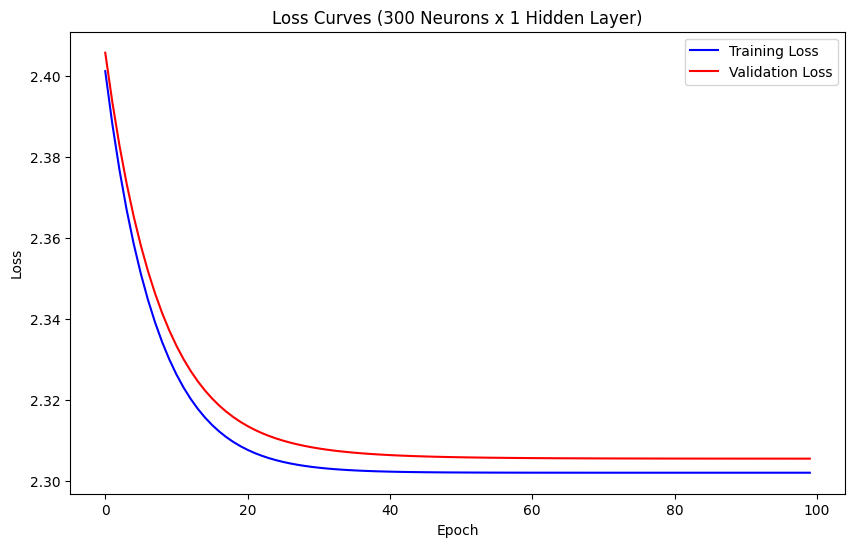

In [68]:
layer_dims1 = [input_dim, 300, 10]
print("Configuration 1: One hidden layer with 300 neurons")
parameters1, train_losses1, val_losses1 = train(X_train, y_train, X_val, y_val, layer_dims1, learning_rate, epochs, activation='sigmoid')
plot_losses(train_losses1, val_losses1, title_suffix="(300 Neurons x 1 Hidden Layer)")

In [75]:
test_accuracy = compute_accuracy(X_test, y_test, parameters1, activation='sigmoid')
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.094


### 1.2) 2 Hidden Layer and 200 Neurons each

Configuration 2: Two hidden layers with 200 neurons each
Epoch 0/100 - Train Loss: 2.3620 - Val Loss: 2.3591
Epoch 10/100 - Train Loss: 2.3204 - Val Loss: 2.3227
Epoch 20/100 - Train Loss: 2.3077 - Val Loss: 2.3112
Epoch 30/100 - Train Loss: 2.3037 - Val Loss: 2.3075
Epoch 40/100 - Train Loss: 2.3025 - Val Loss: 2.3062
Epoch 50/100 - Train Loss: 2.3021 - Val Loss: 2.3057
Epoch 60/100 - Train Loss: 2.3020 - Val Loss: 2.3056
Epoch 70/100 - Train Loss: 2.3019 - Val Loss: 2.3055
Epoch 80/100 - Train Loss: 2.3019 - Val Loss: 2.3054
Epoch 90/100 - Train Loss: 2.3019 - Val Loss: 2.3054


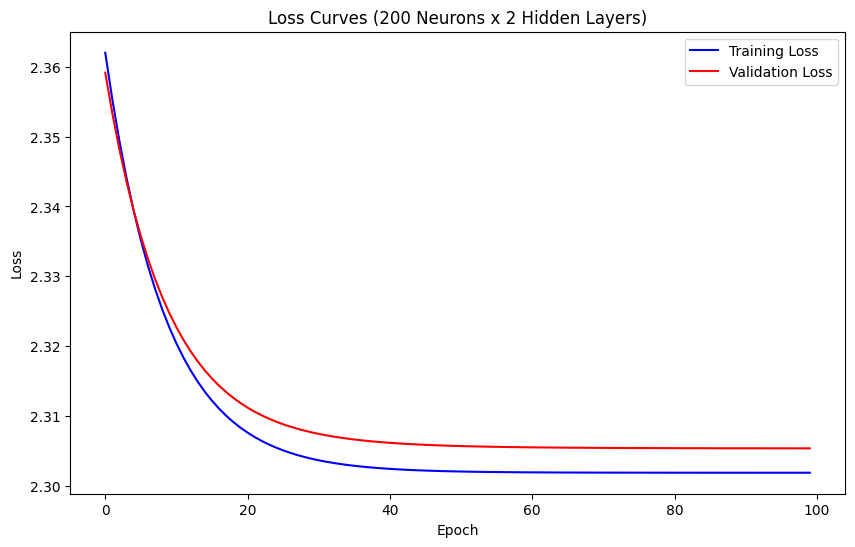

In [76]:
layer_dims2 = [input_dim, 200, 200, 10]
print("Configuration 2: Two hidden layers with 200 neurons each")
parameters2, train_losses2, val_losses2 = train(X_train, y_train, X_val, y_val, layer_dims2, learning_rate, epochs, activation='sigmoid')
plot_losses(train_losses2, val_losses2, title_suffix="(200 Neurons x 2 Hidden Layers)")

In [78]:
test_acc2 = compute_accuracy(X_test, y_test, parameters2, activation='sigmoid')
print(f"Test Accuracy (Config 2): {test_acc2}")

Test Accuracy (Config 2): 0.094


### 1.3) 3 Hidden Layers with 200 Neurons each

Configuration 3: Three hidden layers with 200 neurons each
Epoch 0/100 - Train Loss: 2.3810 - Val Loss: 2.3755
Epoch 10/100 - Train Loss: 2.3229 - Val Loss: 2.3256
Epoch 20/100 - Train Loss: 2.3081 - Val Loss: 2.3121
Epoch 30/100 - Train Loss: 2.3038 - Val Loss: 2.3078
Epoch 40/100 - Train Loss: 2.3025 - Val Loss: 2.3064
Epoch 50/100 - Train Loss: 2.3021 - Val Loss: 2.3058
Epoch 60/100 - Train Loss: 2.3020 - Val Loss: 2.3056
Epoch 70/100 - Train Loss: 2.3019 - Val Loss: 2.3055
Epoch 80/100 - Train Loss: 2.3019 - Val Loss: 2.3054
Epoch 90/100 - Train Loss: 2.3019 - Val Loss: 2.3054


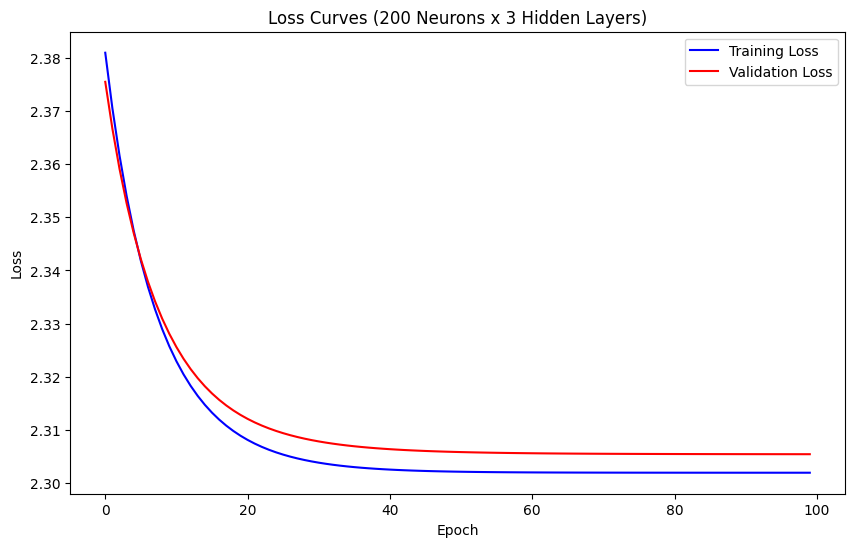

In [79]:
layer_dims3 = [input_dim, 200, 200, 200, 10]
print("Configuration 3: Three hidden layers with 200 neurons each")
parameters3, train_losses3, val_losses3 = train(X_train, y_train, X_val, y_val, layer_dims3, learning_rate, epochs, activation='sigmoid')
plot_losses(train_losses3, val_losses3, title_suffix="(200 Neurons x 3 Hidden Layers)")

In [80]:
test_acc3 = compute_accuracy(X_test, y_test, parameters3, activation='sigmoid')
print(f"Test Accuracy (Config 3): {test_acc3}")

Test Accuracy (Config 3): 0.094


## 2. Using tanh as activation

### 2.1) 1 hidden layer with 300 neurons

Configuration 4: One hidden layer with 300 neurons with tanh
Epoch 0/100 - Train Loss: 2.3028 - Val Loss: 2.3027
Epoch 10/100 - Train Loss: 2.3027 - Val Loss: 2.3028
Epoch 20/100 - Train Loss: 2.3027 - Val Loss: 2.3028
Epoch 30/100 - Train Loss: 2.3027 - Val Loss: 2.3028
Epoch 40/100 - Train Loss: 2.3027 - Val Loss: 2.3029
Epoch 50/100 - Train Loss: 2.3026 - Val Loss: 2.3029
Epoch 60/100 - Train Loss: 2.3026 - Val Loss: 2.3030
Epoch 70/100 - Train Loss: 2.3026 - Val Loss: 2.3030
Epoch 80/100 - Train Loss: 2.3026 - Val Loss: 2.3030
Epoch 90/100 - Train Loss: 2.3026 - Val Loss: 2.3031


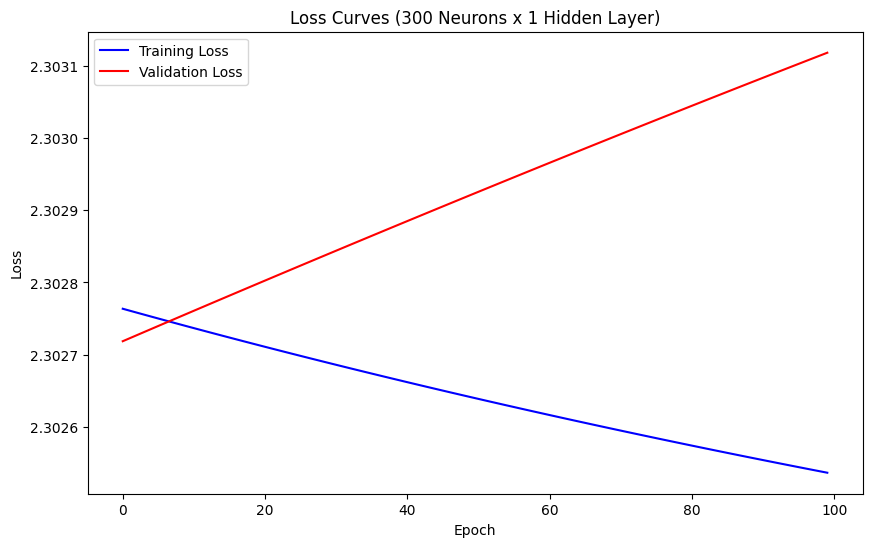

In [81]:
layer_dims4 = [input_dim, 300, 10]
print("Configuration 4: One hidden layer with 300 neurons with tanh")
parameters4, train_losses4, val_losses4 = train(X_train, y_train, X_val, y_val, layer_dims4, learning_rate, epochs, activation='tanh')
plot_losses(train_losses4, val_losses4, title_suffix="(300 Neurons x 1 Hidden Layer)")

In [91]:
test_acc4 = compute_accuracy(X_test, y_test, parameters4, activation='tanh')
print(f"Test Accuracy (Config 4): {test_acc4}")

Test Accuracy (Config 4): 0.094


### 2.2) 2 Hidden Layer and 200 Neurons each

Configuration 5: Two hidden layers with 200 neurons each
Epoch 0/100 - Train Loss: 2.3026 - Val Loss: 2.3027
Epoch 10/100 - Train Loss: 2.3026 - Val Loss: 2.3027
Epoch 20/100 - Train Loss: 2.3025 - Val Loss: 2.3028
Epoch 30/100 - Train Loss: 2.3025 - Val Loss: 2.3028
Epoch 40/100 - Train Loss: 2.3025 - Val Loss: 2.3029
Epoch 50/100 - Train Loss: 2.3024 - Val Loss: 2.3030
Epoch 60/100 - Train Loss: 2.3024 - Val Loss: 2.3030
Epoch 70/100 - Train Loss: 2.3024 - Val Loss: 2.3031
Epoch 80/100 - Train Loss: 2.3023 - Val Loss: 2.3032
Epoch 90/100 - Train Loss: 2.3023 - Val Loss: 2.3032


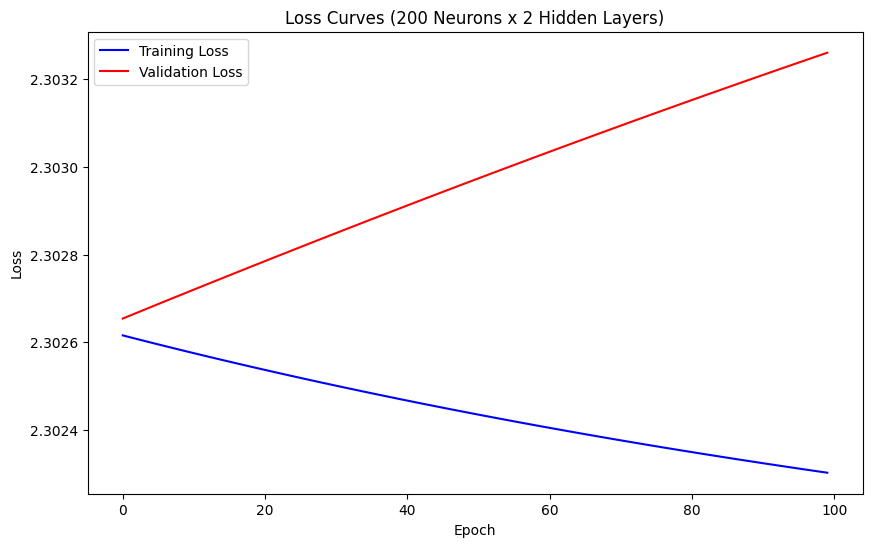

In [84]:
layer_dims5 = [input_dim, 200, 200, 10]
print("Configuration 5: Two hidden layers with 200 neurons each")
parameters5, train_losses5, val_losses5 = train(X_train, y_train, X_val, y_val, layer_dims5, learning_rate, epochs, activation='tanh')
plot_losses(train_losses5, val_losses5, title_suffix="(200 Neurons x 2 Hidden Layers)")

In [89]:
test_acc5 = compute_accuracy(X_test, y_test, parameters5, activation='tanh')
print(f"Test Accuracy (Config 5): {test_acc5}")

Test Accuracy (Config 5): 0.111


### 1.3) 3 Hidden Layers with 200 Neurons each

Configuration 6: Three hidden layers with 200 neurons each
Epoch 0/100 - Train Loss: 2.3026 - Val Loss: 2.3026
Epoch 10/100 - Train Loss: 2.3026 - Val Loss: 2.3027
Epoch 20/100 - Train Loss: 2.3025 - Val Loss: 2.3028
Epoch 30/100 - Train Loss: 2.3025 - Val Loss: 2.3028
Epoch 40/100 - Train Loss: 2.3024 - Val Loss: 2.3029
Epoch 50/100 - Train Loss: 2.3024 - Val Loss: 2.3030
Epoch 60/100 - Train Loss: 2.3023 - Val Loss: 2.3031
Epoch 70/100 - Train Loss: 2.3023 - Val Loss: 2.3032
Epoch 80/100 - Train Loss: 2.3023 - Val Loss: 2.3032
Epoch 90/100 - Train Loss: 2.3022 - Val Loss: 2.3033


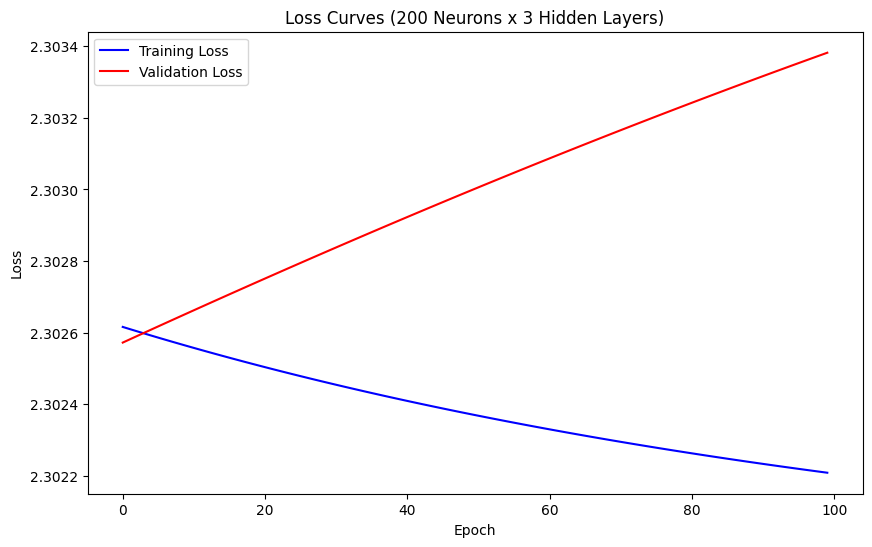

In [86]:
layer_dims6 = [input_dim, 200, 200, 200, 10]
print("Configuration 6: Three hidden layers with 200 neurons each")
parameters6, train_losses6, val_losses6 = train(X_train, y_train, X_val, y_val, layer_dims6, learning_rate, epochs, activation='tanh')
plot_losses(train_losses6, val_losses6, title_suffix="(200 Neurons x 3 Hidden Layers)")

In [90]:
test_acc6 = compute_accuracy(X_test, y_test, parameters6, activation='tanh')
print(f"Test Accuracy (Config 6): {test_acc6}")

Test Accuracy (Config 6): 0.127
